In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import plot_tree

In [2]:
fires = pd.read_csv('fire_climate_dataset.csv')
fires = pd.DataFrame(fires)

fires.head()

,datecurrent,fireyear,incidentname,perimeterdatetime,gisacres,lat,lon,geometry,index_right,NAME,fire_date,year,month,lon_adj,date,temp_month,precip_month
0,2010-09-15 00:00:00,2005,18 ROAD,2005-07-16 19:37:00,17.511509,39.262110,-108.705537,POINT (-108.70553651118293 39.26211028721491),284,Mesa County,2005-07-16 19:37:00,2005,7,251.294463,2005-07-16 19:37:00,80.060176,0.001951
1,2017-12-06 00:00:00,2017,18 Road,2017-05-27 00:00:00,0.707301,39.246299,-108.700311,POINT (-108.70031098965698 39.24629893091578),284,Mesa County,2017-05-27 00:00:00,2017,5,251.299689,2017-05-27 00:00:00,61.228730,0.035027
2,2016-11-02 00:00:00,2016,18 Road Tracer,2016-07-18 00:00:00,0.123598,39.261301,-108.714669,POINT (-108.71466931820386 39.26130103067896),284,Mesa County,2016-07-18 00:00:00,2016,7,251.285331,2016-07-18 00:00:00,78.095381,0.015024
3,2015-09-29 00:00:00,2015,20 Mile,2015-09-18 09:45:00,7.225905,40.748563,-107.756655,POINT (-107.75665455337936 40.74856283988963),286,Moffat County,2015-09-18 09:45:00,2015,9,252.243345,2015-09-18 09:45:00,61.494160,0.027260
4,2017-12-06 00:00:00,2017,21 Road,2017-05-30 00:00:00,28.773811,39.208467,-108.654979,POINT (-108.65497938900153 39.20846708841309),284,Mesa County,2017-05-30 00:00:00,2017,5,251.345021,2017-05-30 00:00:00,61.228730,0.035027


In [3]:
fires_lim = fires[['lat','lon','year','month','temp_month','precip_month','gisacres']]
fires_lim.head()

,lat,lon,year,month,temp_month,precip_month,gisacres
0,39.262110,-108.705537,2005,7,80.060176,0.001951,17.511509
1,39.246299,-108.700311,2017,5,61.228730,0.035027,0.707301
2,39.261301,-108.714669,2016,7,78.095381,0.015024,0.123598
3,40.748563,-107.756655,2015,9,61.494160,0.027260,7.225905
4,39.208467,-108.654979,2017,5,61.228730,0.035027,28.773811


In [4]:
fires_lim['gisacres'].describe()

count       947.000000
mean       1895.349899
std        8519.749726
min           0.030140
25%          17.890754
50%          75.255779
75%         454.380382
max      137894.518963
Name: gisacres, dtype: float64

In [5]:
#Set target to be greater than the average size of fire
fires_lim['fires_target']=(fires_lim['gisacres']>454).astype(int)
fires_lim.tail()

,lat,lon,year,month,temp_month,precip_month,gisacres,fires_target
942,40.504803,-108.038334,2018,11,29.393867,0.041554,6.225466,0
943,40.072005,-108.376649,2001,7,74.061201,0.016670,64.221303,0
944,39.794452,-108.431148,2003,7,75.466572,0.016696,1499.269098,1
945,40.120486,-108.609938,2000,1,20.360029,0.042817,571.392103,1
946,40.065963,-108.285937,2002,8,71.137959,0.030319,26.657241,0


In [6]:
fires_lim.to_csv('fires_target')

In [7]:
fires_lim['fires_target'].value_counts()

fires_target
0    710
1    237
Name: count, dtype: int64

In [8]:
features = ['lat','lon','year','month','temp_month','precip_month']
target = 'fires_target'

corr = fires_lim[features].corr()
corr

,lat,lon,year,month,temp_month,precip_month
lat,1.000000,-0.169335,0.035282,-0.043938,0.062057,-0.204049
lon,-0.169335,1.000000,0.126582,-0.038008,-0.269913,0.274776
year,0.035282,0.126582,1.000000,0.138557,0.200201,0.070491
month,-0.043938,-0.038008,0.138557,1.000000,0.159359,0.046121
temp_month,0.062057,-0.269913,0.200201,0.159359,1.000000,-0.297729
precip_month,-0.204049,0.274776,0.070491,0.046121,-0.297729,1.000000


In [9]:
X_train, X_test, y_train, y_test = train_test_split(fires_lim[features], fires_lim[target], test_size = 0.2, random_state = 0)

In [10]:
# No. of instance with 1 in target variable for training set
display(y_train.value_counts())

# No. of instance with 1 in target variable for test set
display(y_test.value_counts())

fires_target
0    568
1    189
Name: count, dtype: int64

fires_target
0    142
1     48
Name: count, dtype: int64

In [11]:
X_train[:5]
#X_test[:5]

,lat,lon,year,month,temp_month,precip_month
62,40.103153,-108.309134,2016,7,75.986006,0.023116
79,37.185050,-108.265079,2007,7,71.824824,0.061421
646,40.217070,-108.386188,2002,6,72.465107,0.011452
181,38.465069,-106.449364,2000,12,11.701924,0.031678
304,39.403644,-108.032354,2008,7,69.183271,0.015847


In [40]:
type(X_train)


numpy.ndarray

In [11]:
#Scale features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)

In [12]:
classifier = DecisionTreeClassifier(random_state = 0, class_weight = 'balanced', max_depth = 4)
classifier.fit(X_train, y_train)
preds = classifier.predict(sc.transform(X_test))

Text(0.5, 1.0, 'Confusion Matrix for Gini Decision Tree Classifier')

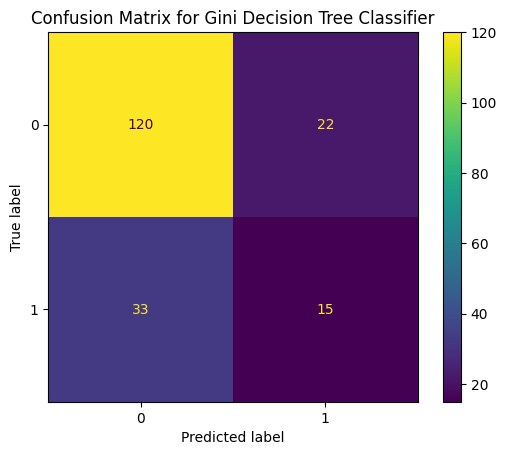

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score

# your code here
cm = confusion_matrix(y_test,preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Gini Decision Tree Classifier')

In [14]:
accuracy = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)
recall = recall_score(y_test, preds)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Recall Score: {recall}')

Accuracy: 0.7105263157894737
F1 Score: 0.35294117647058826
Recall Score: 0.3125


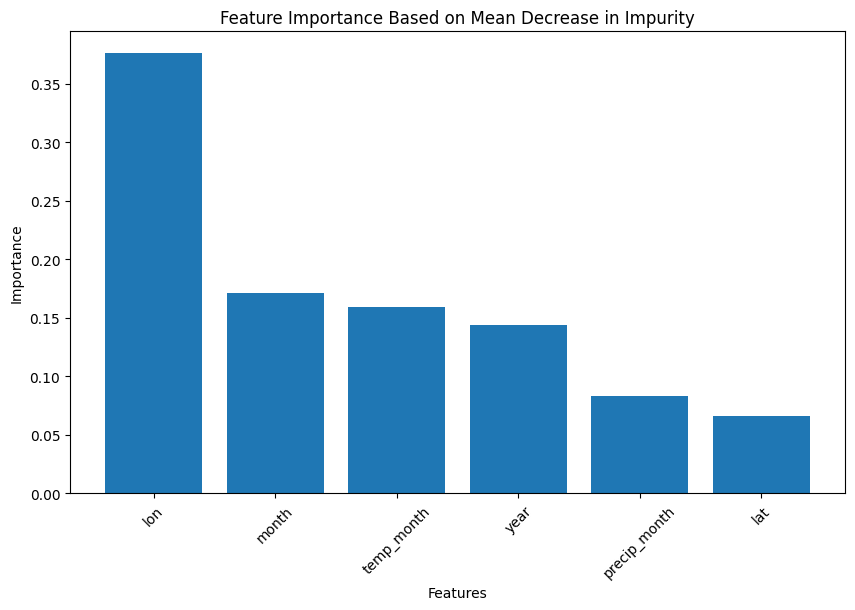

In [15]:
importances = classifier.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance Based on Mean Decrease in Impurity")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [16]:
classifier2 = RandomForestClassifier(random_state = 0, class_weight = 'balanced',max_depth = 4)
classifier2.fit(X_train, y_train)
preds2 = classifier2.predict(sc.transform(X_test))

Text(0.5, 1.0, 'Confusion Matrix for Random Forest Classifier')

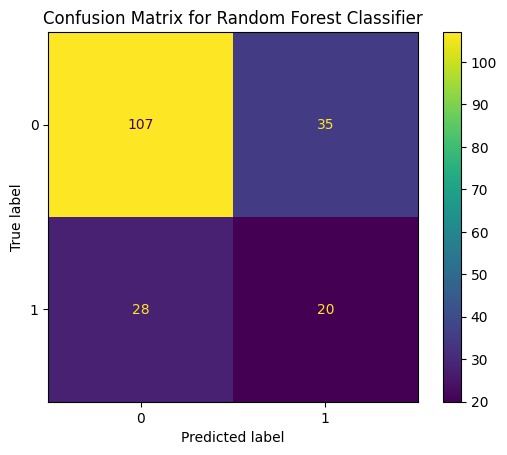

In [17]:
cm = confusion_matrix(y_test,preds2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier2.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Random Forest Classifier')

In [18]:
accuracy = accuracy_score(y_test, preds2)
f1 = f1_score(y_test, preds2)
recall = recall_score(y_test, preds2)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Recall Score: {recall}')

Accuracy: 0.6684210526315789
F1 Score: 0.3883495145631068
Recall Score: 0.4166666666666667


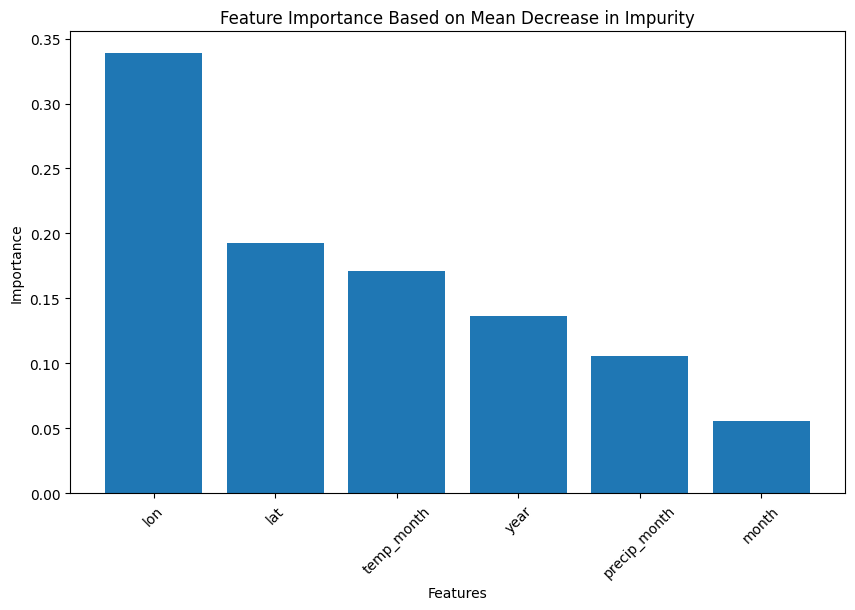

In [19]:
importances = classifier2.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance Based on Mean Decrease in Impurity")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

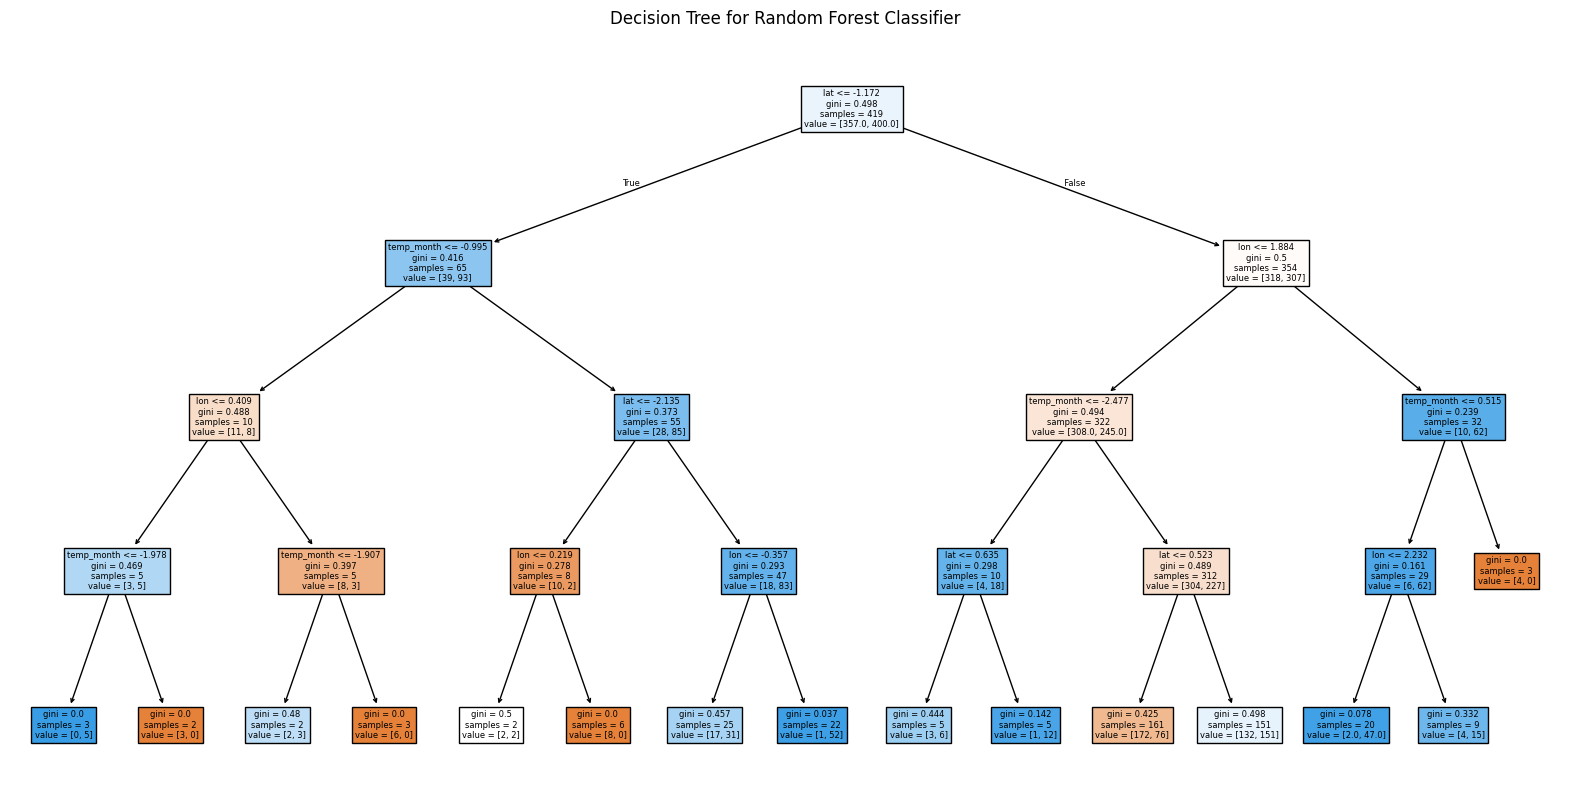

In [20]:
plt.figure(figsize=(20, 10))
plot_tree(classifier2.estimators_[0], feature_names=features, filled=True)
plt.title('Decision Tree for Random Forest Classifier')
plt.show()

In [21]:
classifier3 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0,max_depth = 4)
classifier3.fit(X_train, y_train)
preds3 = classifier3.predict(sc.transform(X_test))

Text(0.5, 1.0, 'Confusion Matrix for Gini Decision Tree Classifier')

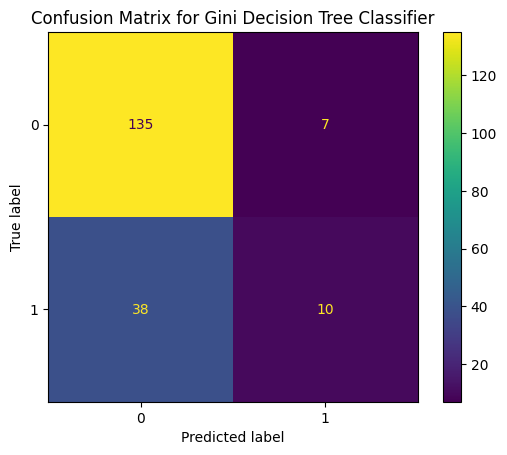

In [22]:
cm3 = confusion_matrix(y_test,preds3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=classifier3.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Gini Decision Tree Classifier')

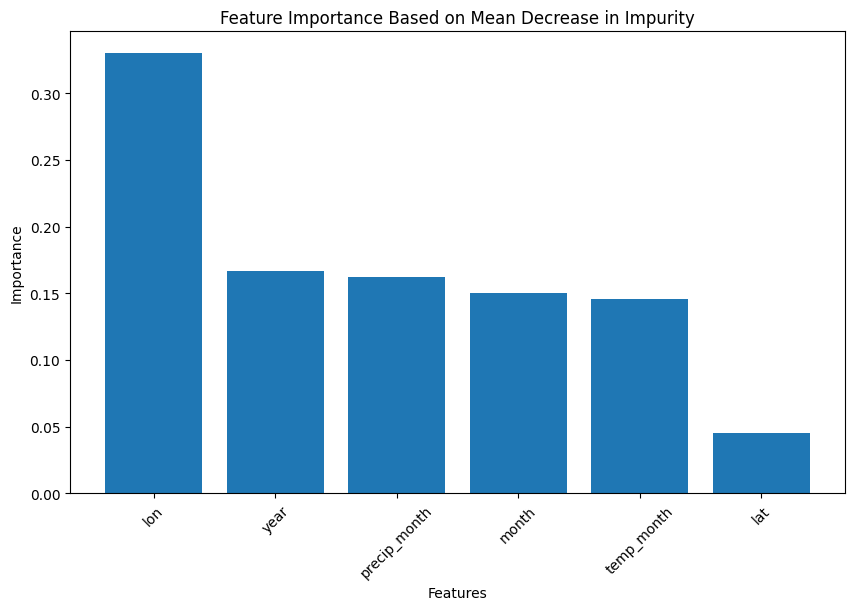

In [23]:
importances = classifier3.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance Based on Mean Decrease in Impurity")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [24]:
accuracy = accuracy_score(y_test, preds3)
f1 = f1_score(y_test, preds3)
recall = recall_score(y_test, preds3)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Recall Score: {recall}')

Accuracy: 0.7631578947368421
F1 Score: 0.3076923076923077
Recall Score: 0.20833333333333334
